# `geoai-datacubes` -- Building detection with YOLO on NAIP

<a href="https://colab.research.google.com/github/buckai-observatory/geoai-datacubes/blob/main/notebooks/02_building_detection.ipynb" target="_blank" rel="noopener noreferrer"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

**Welcome.** This is the third pedagogical notebook in the `geoai-datacubes`
trilogy. The first (`00_geoai_datacubes_tour.ipynb`) walks you through the
data-acquisition side of the pipeline; the second
(`01_classification.ipynb`) trains four standard classifiers for a
binary **semantic-segmentation** target (every pixel gets a class label).

This notebook switches the modelling problem from *labelling pixels* to
**detecting objects** -- drawing one bounding box around each individual
building. Object detection is the right framing whenever the downstream
question is *"how many of X are there, and where exactly?"* rather than
*"what fraction of the scene is X?"*. Damage-assessment after a hurricane,
parking-lot counting, illegal-construction monitoring, ship spotting in
ports: all of these are object detection, not segmentation.

Concretely you will:

1. Fetch NAIP (1 m public-domain US aerial imagery) over Columbus, Cincinnati,
   and Cleveland through the pipeline's new `NAIP` mission profile.
2. Download the Microsoft US Building Footprints dataset for Ohio (a free,
   permissively-licensed polygon ground truth) and clip it to each AOI.
3. Convert the polygon ground truth into **YOLO-format bounding-box
   labels** -- the boring-but-critical glue step that makes any
   detector trainable.
4. Train a tiny **YOLOv8n** model (the "nano" Ultralytics variant -- 3.2 M
   parameters) for ~80 epochs on CPU and report mAP@0.5, mAP@0.5:0.95,
   precision, and recall.
5. Sanity-check the result visually with a side-by-side
   ground-truth-vs-prediction panel.
6. Stop in the middle for a **resolution-comparison sidebar**: the same
   neighbourhood at 1 m (NAIP) vs 10 m (Sentinel-2), because the single
   most important reason object detection on satellite imagery fails is
   that the operator pointed it at imagery whose pixels are larger than
   the objects of interest.

Runs end-to-end on a Colab CPU in roughly 15-30 minutes; most of the time
is spent waiting for NAIP to download and YOLO to converge.

> *Why buildings?* Buildings are a great pedagogical target because the
> visual signal (rectangular blob with a clear shadow on one side) is
> unambiguous to a human reader, ground-truth polygons are freely
> available state-wide, and the object scale (~10 x 10 m) sits right at the
> boundary where imagery resolution starts to matter. That last property
> is what lets the resolution-comparison sidebar land hard.

## 1. Setup

Standard Colab / local bootstrap. On Colab, this clones the repo into
`/content/geoai-datacubes` and pip-installs the handful of extras Colab
does not ship with (most importantly `ultralytics`, the Python package
that fronts the YOLO models we will train). Locally it is a no-op that
just confirms the layout.

In [1]:
# --- Colab / local bootstrap ---
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Colab detected -- bootstrapping repo + dependencies")
    REPO_DIR = Path("/content/geoai-datacubes")
    if not REPO_DIR.exists():
        subprocess.check_call([
            "git", "clone", "--depth", "1",
            "https://github.com/buckai-observatory/geoai-datacubes.git",
            str(REPO_DIR),
        ])
    else:
        print(f"repo already cloned at {REPO_DIR}")

    # Colab pre-installs rasterio / shapely / scikit-image / scipy / tqdm /
    # pandas / pyproj / requests / matplotlib / scikit-learn / torch.
    # These extras may be missing for this notebook:
    missing = []
    for pkg, importname in [("pystac",      "pystac"),
                            ("contextily",  "contextily"),
                            ("geopandas",   "geopandas"),
                            ("ultralytics", "ultralytics")]:
        try:
            __import__(importname)
        except ImportError:
            missing.append(pkg)
    if missing:
        print(f"pip install -q {' '.join(missing)}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

    os.chdir(REPO_DIR / "notebooks")
    print(f"cwd = {os.getcwd()}")
else:
    print("Local environment -- using existing checkout")

Local environment -- using existing checkout


Imports, `sys.path` setup so the `geoai_datacubes` package is importable,
and a scratch folder `notebooks/_outputs_obj/` for everything this
notebook writes (gitignored).

In [2]:
# --- imports + path setup ---
import glob, os, sys, json, shutil, time, math, warnings, random, zipfile, io, re
from pathlib import Path

# Keep CPU threading conservative -- YOLO + sklearn + matplotlib coexist
# better with a small thread pool on a laptop CPU.
os.environ.setdefault("OMP_NUM_THREADS",      "2")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")
os.environ.setdefault("MKL_NUM_THREADS",      "2")
os.environ.setdefault("NUMEXPR_NUM_THREADS",  "2")

import numpy as np
import pandas as pd
import rasterio
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from PIL import Image  # used by the figure cells in sections 7 + 10

NB_DIR = Path.cwd()
if NB_DIR.name != "notebooks":
    for p in (NB_DIR, *NB_DIR.parents):
        if (p / "notebooks").is_dir() and (p / "geoai_datacubes").is_dir():
            NB_DIR = p / "notebooks"
            break
REPO_ROOT = NB_DIR.parent
sys.path.insert(0, str(REPO_ROOT))

OUT       = NB_DIR / "_outputs_obj"
NAIP_DIR  = OUT / "naip"
S2_DIR    = OUT / "s2"
TILES_DIR = OUT / "tiles"
LBL_DIR   = OUT / "labels"
YOLO_DIR  = OUT / "yolo"
RUNS_DIR  = OUT / "runs"
for d in (OUT, NAIP_DIR, S2_DIR, TILES_DIR, LBL_DIR, YOLO_DIR, RUNS_DIR):
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"]  = 90
plt.rcParams["savefig.dpi"] = 90
plt.rcParams["axes.grid"]   = False
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Repo root :", REPO_ROOT)
print("Package   :", REPO_ROOT / "geoai_datacubes")
print("Outputs   :", OUT)

Repo root : /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes
Package   : /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes/geoai_datacubes
Outputs   : /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes/notebooks/_outputs_obj


Pull in the four pieces of the pipeline this notebook actually uses --
the AOI resolver, the mission table (so we can read NAIP and Sentinel-2's
profiles), the fetcher itself, and PyTorch / Ultralytics.

In [3]:
from geoai_datacubes.fetch import resolve_aoi
from geoai_datacubes.fetch import MISSION_PROFILES, get_profile
from geoai_datacubes.fetch import fetch_sentinel_data, fetch_many_in_parallel
from geoai_datacubes.ml_dl import (
    polygons_to_yolo_tiles,
    write_yolo_data_yaml,
    draw_yolo_boxes,
    pick_tiles_with_boxes,
    train_yolo_detector,
    validate_yolo_model,
    box_iou,
    yolo_lines_to_pixel_boxes,
)

import torch
from ultralytics import YOLO
torch.manual_seed(SEED)
torch.set_num_threads(2)

print("Available missions:", sorted(MISSION_PROFILES.keys()))
print("torch:", torch.__version__, "(device: cpu)")
from ultralytics import __version__ as ULTRA_VER
print("ultralytics:", ULTRA_VER)

import geopandas as gpd
import shapely
from shapely.geometry import box as sh_box, Polygon, MultiPolygon
print("geopandas:", gpd.__version__, "   shapely:", shapely.__version__)


Available missions: ['3DEP', 'Copernicus-DEM', 'ESA-WorldCover', 'HLS_L30', 'HLS_S30', 'JRC-GSW', 'Landsat', 'Landsat-8', 'Landsat-9', 'MODIS_LST', 'MODIS_SR', 'NAIP', 'PlanetScope-4b', 'PlanetScope-8b', 'Sentinel-1', 'Sentinel-2', 'Sentinel-2-L1C', 'Sentinel-5P']
torch: 2.8.0 (device: cpu)
ultralytics: 8.4.71
geopandas: 0.12.2    shapely: 1.8.2


## 2. USER INPUT

Three AOIs, one per city, with the same lat/lon centres notebook 01 uses.
NAIP at 1 m delivers about a million pixels per square mile, so we keep
each AOI a bit smaller than the 4 mi squares of notebook 01 -- a 5 mi
side is generous enough to give YOLO a few hundred 512 m tiles per city
(comfortably above the small-dataset floor where YOLO bounces around at
random) while still decompressing the COGs in a few minutes per city on
a typical connection.

The time window covers 2022-2024 so we pick up the latest Ohio NAIP
acquisition (2023 in this case).

In [4]:
# ============================================================
# USER INPUT
# ============================================================
CITY_AOIS = {
    "columbus":   {"center": (40.0067, -83.0305), "side_miles": 5.0, "role": "train"},
    "cincinnati": {"center": (39.0997, -84.5147), "side_miles": 5.0, "role": "val"},
    "cleveland":  {"center": (41.4993, -81.6944), "side_miles": 5.0, "role": "test"},
}

for city, spec in CITY_AOIS.items():
    spec["bbox"] = resolve_aoi({"center": spec["center"],
                                "side_miles": spec["side_miles"]})

# Time window -- latest available NAIP acquisition for Ohio is 2023.
TIME_RANGE_NAIP = ("2022-01-01", "2024-12-31")

# Tile geometry -- 512 x 512 px tiles at 1 m GSD = 512 m square ground footprint.
TILE_PX  = 512
NAIP_RES = 1.0   # metres per pixel

# ---- Training cache -----------------------------------------------
# When True (default), the YOLO training cell skips the full 80-epoch
# fit() if a `best.pt` is already present under
# notebooks/_outputs_obj/runs/building_det/weights/. The repo ships a
# trained checkpoint so a fresh Colab launch lands in ~5 minutes
# instead of ~30-60. Set False to force re-training even when the
# weights file exists.
USE_CACHED_MODELS = True

for city, spec in CITY_AOIS.items():
    bb = spec["bbox"]
    h_km = (bb[3] - bb[1]) * 111.0
    w_km = (bb[2] - bb[0]) * 111.0 * math.cos(math.radians(bb[1]))
    print(f"{city:11s}  role={spec['role']:5s}  side={spec['side_miles']} mi"
          f"  bbox={[round(x,3) for x in bb]}  ({h_km:.2f} x {w_km:.2f} km)")
print(f"\nTime window     : {TIME_RANGE_NAIP[0]} .. {TIME_RANGE_NAIP[1]}")
print(f"Tile geometry   : {TILE_PX} x {TILE_PX} px at {NAIP_RES} m -> "
      f"{TILE_PX*NAIP_RES:.0f} m square per tile")


columbus     role=train  side=5.0 mi  bbox=[-83.078, 39.97, -82.983, 40.043]  (8.04 x 8.03 km)
cincinnati   role=val    side=5.0 mi  bbox=[-84.561, 39.063, -84.468, 39.136]  (8.04 x 8.03 km)
cleveland    role=test   side=5.0 mi  bbox=[-81.743, 41.463, -81.646, 41.536]  (8.04 x 8.03 km)

Time window     : 2022-01-01 .. 2024-12-31
Tile geometry   : 512 x 512 px at 1.0 m -> 512 m square per tile


## 3. Fetch NAIP for each city

NAIP comes through Microsoft Planetary Computer, no credentials needed.
The dispatcher routes `mission="NAIP"` to `provider="planetary_computer"`
automatically. The fetcher writes one `<Mission>_full_size.tiff` per scene
under `_outputs_obj/naip/`.

NAIP is delivered as a **single multi-band COG** with R / G / B / NIR in
bands 1-4. The pipeline's `asset_map` uses `(asset_key, band_index)`
tuples to reach into that one asset; everything else in the fetch flow
works just like Sentinel-2.

In [5]:
%%time
# --- helper: detect whether an AOI is already fully covered by a cached NAIP mosaic ---
def _has_naip_for_aoi(city_bbox):
    """Return the cached scene folder whose NAIP_full_size.tiff fully covers
    `city_bbox`, or None if no such cache exists. Lets a re-run skip the
    (slow!) Planetary-Computer NAIP fetch when the previous run already
    landed a mosaic that covers the AOI."""
    from rasterio.warp import transform_bounds
    for d in sorted(NAIP_DIR.glob("NAIP_*")):
        tif = d / "NAIP_full_size.tiff"
        if not tif.exists():
            continue
        try:
            with rasterio.open(tif) as src:
                lb = transform_bounds(src.crs, "EPSG:4326", *src.bounds)
        except Exception:
            continue
        if (lb[0] <= city_bbox[0] and lb[1] <= city_bbox[1] and
            lb[2] >= city_bbox[2] and lb[3] >= city_bbox[3]):
            return d
    return None


# Split the cities into cached vs not-cached. Cached ones are free; the
# rest run concurrently through fetch_many_in_parallel so the per-city
# downloads overlap instead of serialising.
cached = {}
to_fetch = {}
for city, spec in CITY_AOIS.items():
    sd = _has_naip_for_aoi(spec["bbox"])
    if sd is not None:
        cached[city] = sd
    else:
        to_fetch[city] = spec

for city, sd in cached.items():
    print(f"  {city:11s}  cached  -> {sd.name}  (skipped)")

if to_fetch:
    print(f"\nFetching NAIP for {len(to_fetch)} city/cities in parallel "
          f"(max_workers={min(3, len(to_fetch))}) ...")
    jobs = [
        {
            "mission":            "NAIP",
            "bands":              ["R", "G", "B", "NIR"],
            "time_range":         TIME_RANGE_NAIP,
            "roi":                spec["bbox"],
            "resolution":         NAIP_RES,
            "save_folder":        str(NAIP_DIR),
            "max_cloud_coverage": 1.0,
        }
        for city, spec in to_fetch.items()
    ]
    labels = list(to_fetch.keys())
    results = fetch_many_in_parallel(jobs, labels=labels,
                                      max_workers=min(3, len(to_fetch)))
    n_ok  = sum(1 for r in results if r["status"] == "ok")
    if n_ok < len(results):
        for r in results:
            if r["status"] == "error":
                print(f"  ERROR for {r['label']}: {r['error']}")
else:
    print("\nAll cities already cached -- nothing to download.")


  columbus     cached  -> NAIP_2023-05-21_oh_m_4008364_se_17_030_20230521_20231018  (skipped)
  cincinnati   cached  -> NAIP_2022-06-30_ky_m_3908460_ne_16_060_20220630  (skipped)
  cleveland    cached  -> NAIP_2023-05-26_oh_m_4108135_nw_17_030_20230526_20231018  (skipped)

All cities already cached -- nothing to download.
CPU times: user 27.6 ms, sys: 13.6 ms, total: 41.2 ms
Wall time: 77.3 ms


Locate the per-city scene folder, read a few key fields from the
GeoTIFF (CRS, pixel grid size, acquisition date encoded in the scene id),
and print a summary line. We will reuse `city_scene[city]` throughout.

In [6]:
def _latest_naip_scene_dir(city_bbox):
    """Pick the cached scene whose tiff best covers `city_bbox`.

    Preference order:
      1. SUPERSETS -- tiffs whose bbox fully covers the AOI; among those,
         the alphabetically-last (newest by date) wins.
      2. Fallback to the partial-overlap candidate with the largest
         bbox-area intersection with the AOI.

    Makes the notebook robust to having multiple cached scenes per city
    (e.g. an old quarter-quad alongside a newer full-AOI mosaic).
    """
    from rasterio.warp import transform_bounds
    supersets = []
    overlaps  = []
    for d in sorted(NAIP_DIR.glob("NAIP_*")):
        tif = d / "NAIP_full_size.tiff"
        if not tif.exists():
            continue
        try:
            with rasterio.open(tif) as src:
                lb = transform_bounds(src.crs, "EPSG:4326", *src.bounds)
        except Exception:
            continue
        if (lb[0] <= city_bbox[0] and lb[1] <= city_bbox[1] and
            lb[2] >= city_bbox[2] and lb[3] >= city_bbox[3]):
            supersets.append(d)
            continue
        ix0 = max(lb[0], city_bbox[0]); iy0 = max(lb[1], city_bbox[1])
        ix1 = min(lb[2], city_bbox[2]); iy1 = min(lb[3], city_bbox[3])
        ov  = max(0.0, ix1 - ix0) * max(0.0, iy1 - iy0)
        if ov > 0:
            overlaps.append((ov, d))
    if supersets:
        return supersets[-1]
    if overlaps:
        overlaps.sort()
        return overlaps[-1][1]
    return None

city_scene = {}
for city, spec in CITY_AOIS.items():
    sd = _latest_naip_scene_dir(spec["bbox"])
    if sd is None:
        raise RuntimeError(f"No NAIP scene folder found for {city}")
    city_scene[city] = sd

print(f"{'city':11s} {'date':10s} {'crs':10s} {'pixels':>15s}  scene_id")
print("-" * 90)
for city, sd in city_scene.items():
    tif = sd / "NAIP_full_size.tiff"
    with rasterio.open(tif) as src:
        h, w = src.shape
        crs  = str(src.crs).replace("EPSG:", "")
        date_str = sd.name.split("_")[1] if "_" in sd.name else "?"
    print(f"{city:11s} {date_str:10s} {crs:10s} {f'{h} x {w}':>15s}  {sd.name}")


city        date       crs                 pixels  scene_id
------------------------------------------------------------------------------------------
columbus    2023-05-21 26917          8221 x 8239  NAIP_2023-05-21_oh_m_4008364_se_17_030_20230521_20231018
cincinnati  2022-06-30 26916          8258 x 8276  NAIP_2022-06-30_ky_m_3908460_ne_16_060_20220630
cleveland   2023-05-26 26917          8104 x 8120  NAIP_2023-05-26_oh_m_4108135_nw_17_030_20230526_20231018


## 4. Download Microsoft US Building Footprints (Ohio)

The ground truth comes from Microsoft's open
[US Building Footprints](https://github.com/microsoft/USBuildingFootprints) --
machine-extracted building outlines covering the entire US, released under
the **Open Data Commons Open Database Licence (ODbL)** so we are allowed
to redistribute derived products.

The next cell tries three load paths in order:

1. **Bundled GeoPackage** -- `notebooks/sample_data/building_footprints_oh_3cities_5mi.gpkg`
   ships in the repo (~18 MB) and covers the committed Columbus / Cincinnati /
   Cleveland 5-mile AOIs. This is the default Colab / fresh-clone path and
   completes in under a second; no download required.
2. **Per-AOI pickle cache** -- when the bundled file is absent but a prior
   run wrote one, we re-use the cached frame keyed on a hash of the AOI
   bounding boxes (so editing `CITY_AOIS` automatically invalidates).
3. **Full state-wide download + stream-filter** (the fallback) -- pull the
   ~180 MB / ~5.5 M-polygon Ohio.geojson.zip from the canonical Microsoft
   mirror, stream-decompress line-by-line, and run a cheap regex bbox
   prefilter to discard ~99.9 % of features outside our AOI union. Finishes
   in ~15 s on a laptop. Used only when neither cache exists.


In [7]:
%%time
OHIO_URL  = "https://minedbuildings.z5.web.core.windows.net/legacy/usbuildings-v2/Ohio.geojson.zip"
OHIO_ZIP  = OUT / "Ohio.geojson.zip"

# Try the bundled GeoPackage first (ships in the repo; saves a 181 MB
# download + ~60 s stream-filter on every Colab cold start).
BUNDLED_FOOTPRINTS = (REPO_ROOT / "notebooks" / "sample_data"
                                / "building_footprints_oh_3cities_5mi.gpkg")

if BUNDLED_FOOTPRINTS.exists():
    print(f"  using bundled  {BUNDLED_FOOTPRINTS.name} "
          f"({BUNDLED_FOOTPRINTS.stat().st_size/1024/1024:.2f} MB)")
elif OHIO_ZIP.exists():
    print(f"  using cached   {OHIO_ZIP.name} "
          f"({OHIO_ZIP.stat().st_size/1024/1024:.1f} MB)")
else:
    print(f"  bundled file not found -- falling back to full download")
    print(f"  Downloading {OHIO_URL}")
    t0 = time.time()
    with requests.get(OHIO_URL, stream=True, timeout=600) as r:
        r.raise_for_status()
        written = 0
        with open(OHIO_ZIP, "wb") as f:
            for chunk in r.iter_content(1024 * 1024):
                f.write(chunk)
                written += len(chunk)
        print(f"  downloaded {written/1024/1024:.1f} MB in {time.time()-t0:.1f} s")


  using bundled  building_footprints_oh_3cities_5mi.gpkg (17.29 MB)
CPU times: user 115 µs, sys: 57 µs, total: 172 µs
Wall time: 153 µs


Build a single union bbox covering all three city AOIs (with a small
pad) so the streaming prefilter only has to do one cheap test per feature.
Then read the file feature-by-feature, dropping any polygon whose first
vertex is outside that union -- this discards roughly 99.9% of the
state-wide records without any JSON parsing.

In [8]:
%%time
def _union_bbox(aois, pad_deg=0.02):
    bbs = [s["bbox"] for s in aois.values()]
    return (min(b[0] for b in bbs) - pad_deg,
            min(b[1] for b in bbs) - pad_deg,
            max(b[2] for b in bbs) + pad_deg,
            max(b[3] for b in bbs) + pad_deg,)

UB = _union_bbox(CITY_AOIS)
print(f"Union bbox (with pad): {[round(x,3) for x in UB]}")

# Path 1: bundled GeoPackage -- ships in the repo, covers the committed
# AOIs (Columbus / Cincinnati / Cleveland, 5-mi square each). No
# download, no filter -- just a one-line read.
if BUNDLED_FOOTPRINTS.exists():
    print(f"Loading bundled footprints from {BUNDLED_FOOTPRINTS.name} ...")
    gdf_all = gpd.read_file(BUNDLED_FOOTPRINTS)
    print(f"  geopandas frame: {len(gdf_all):,} rows, crs={gdf_all.crs}")

else:
    # Path 2 / 3 fall back to per-AOI pickle cache or stream-filter from
    # the zip. The cache key hashes the AOI signature so editing
    # CITY_AOIS automatically invalidates.
    import hashlib, pickle
    _aoi_key_parts = []
    for _city, _spec in sorted(CITY_AOIS.items()):
        _aoi_key_parts.append((_city, tuple(round(x, 5) for x in _spec["bbox"])))
    _aoi_key = hashlib.md5(repr(_aoi_key_parts).encode()).hexdigest()[:10]
    FOOTPRINTS_CACHE = OUT / f"footprints_aoi_{_aoi_key}.pkl"

    if FOOTPRINTS_CACHE.exists():
        print(f"Loading AOI footprints from {FOOTPRINTS_CACHE.name} "
              f"({FOOTPRINTS_CACHE.stat().st_size/1024/1024:.2f} MB)")
        with open(FOOTPRINTS_CACHE, "rb") as f:
            gdf_all = pickle.load(f)
        print(f"  geopandas frame: {len(gdf_all):,} rows, crs={gdf_all.crs}")
    else:
        # Stream-extract candidate features (the unzipped Ohio.geojson is
        # over a gigabyte; streaming keeps the resident set small).
        print(f"Streaming-filtering {OHIO_ZIP.name} into the AOI union bbox ...")
        t0 = time.time()
        features = []
        with zipfile.ZipFile(OHIO_ZIP) as z:
            with z.open("Ohio.geojson") as raw:
                reader = io.TextIOWrapper(raw, encoding="utf-8")
                coord0 = re.compile(r'\[\[([-0-9.]+),([-0-9.]+)\]')
                for line in reader:
                    s = line.strip().rstrip(",")
                    if not s.startswith('{"type":"Feature"'):
                        continue
                    m = coord0.search(s)
                    if not m:
                        continue
                    lon = float(m.group(1)); lat = float(m.group(2))
                    if not (UB[0] <= lon <= UB[2] and UB[1] <= lat <= UB[3]):
                        continue
                    try:
                        features.append(json.loads(s))
                    except Exception:
                        continue
        elapsed = time.time() - t0
        print(f"  kept {len(features):,} polygons in {elapsed:.1f} s "
              f"(out of ~5.5M state-wide)")

        fc = {"type": "FeatureCollection", "features": features}
        gdf_all = gpd.GeoDataFrame.from_features(fc, crs="EPSG:4326")
        print(f"  geopandas frame: {len(gdf_all):,} rows, crs={gdf_all.crs}")

        with open(FOOTPRINTS_CACHE, "wb") as f:
            pickle.dump(gdf_all, f, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"  cached AOI footprints to {FOOTPRINTS_CACHE.name} "
              f"({FOOTPRINTS_CACHE.stat().st_size/1024/1024:.2f} MB)")


Union bbox (with pad): [-84.581, 39.043, -81.626, 41.556]
Loading bundled footprints from building_footprints_oh_3cities_5mi.gpkg ...


  geopandas frame: 83,459 rows, crs=epsg:4326
CPU times: user 1.23 s, sys: 201 ms, total: 1.43 s
Wall time: 1.3 s


Reproject the candidate frame to **each NAIP scene's CRS** -- not a
hard-coded zone, because Cincinnati's NAIP scene actually comes from the
Kentucky NAIP archive (UTM zone 16, EPSG:26916) while Columbus and
Cleveland sit in Ohio's UTM zone 17 (EPSG:26917). Looking up the CRS per
scene keeps the per-city footprints aligned with the per-city image and
prevents the silent drop-everything-to-zero-boxes failure mode that
otherwise hits Cincinnati. Then clip per city AOI so each city has its
own clean footprint set, and report counts (and the resolved CRS) so the
reader can sanity-check that the regex prefilter didn't drop anything
unexpected.


In [9]:
%%time
# Per-city footprint clipping. We reproject the global geographic frame
# to **each NAIP scene's actual CRS** rather than hard-coding UTM 17
# (Ohio): Cincinnati's NAIP scene happens to come from the Kentucky NAIP
# archive in UTM 16, and a hard-coded 26917 reprojection landed those
# 11k+ buildings in the wrong coordinate system -- the YOLO conversion
# silently dropped them and val mAP came out at 0. Per-scene CRS lookup
# avoids that.

city_footprints = {}
city_aoi_utm    = {}   # AOI bbox in the scene's CRS (shapely polygon)
for city, spec in CITY_AOIS.items():
    with rasterio.open(city_scene[city] / "NAIP_full_size.tiff") as src:
        scene_crs = src.crs
    sub_all = gdf_all.to_crs(scene_crs)

    bb_ll  = spec["bbox"]
    aoi_ll = gpd.GeoSeries([sh_box(*bb_ll)], crs="EPSG:4326").to_crs(scene_crs)
    aoi_utm = aoi_ll.iloc[0]
    city_aoi_utm[city] = aoi_utm

    sub = sub_all[sub_all.intersects(aoi_utm)].copy()
    sub["geometry"] = sub.geometry.intersection(aoi_utm)
    sub = sub[~sub.geometry.is_empty]
    city_footprints[city] = sub
    print(f"  {city:11s}: {len(sub):>6,} buildings in AOI  (scene CRS {scene_crs})")


  columbus   : 36,874 buildings in AOI  (scene CRS EPSG:26917)


  cincinnati : 11,812 buildings in AOI  (scene CRS EPSG:26916)


  cleveland  : 16,825 buildings in AOI  (scene CRS EPSG:26917)
CPU times: user 15.2 s, sys: 113 ms, total: 15.3 s
Wall time: 15.3 s


## 5. Visualise the ground truth

For each city we show the NAIP RGB composite for the AOI extent with the
clipped building footprints overlaid in red. This is the "look how dense
the labels are" sanity check -- if the overlay shows buildings landing in
the streets, we have a CRS or coordinate-order bug to fix before going
any further.

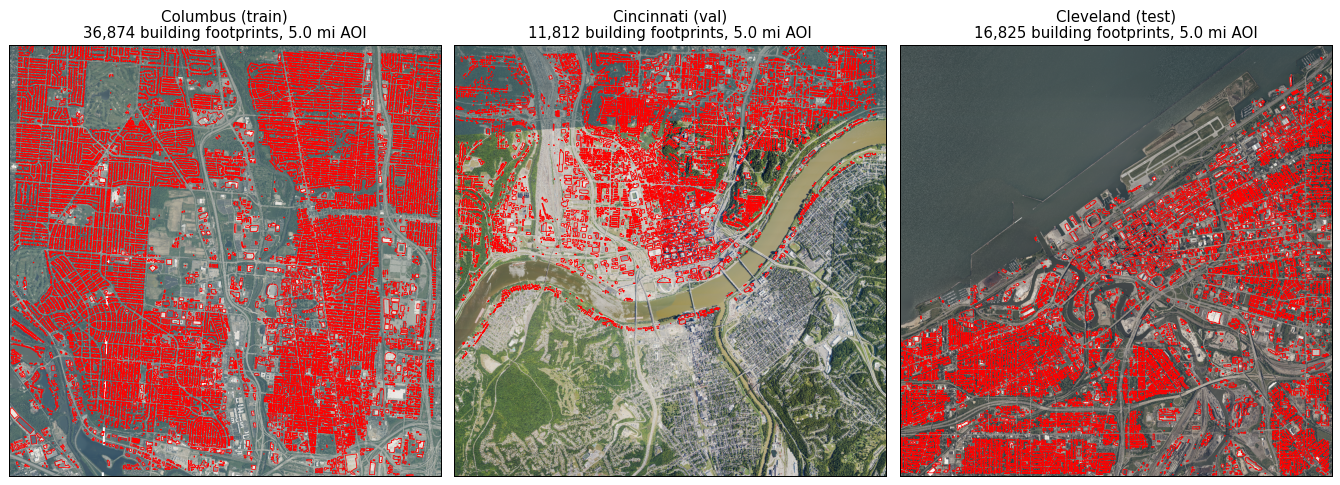

CPU times: user 19.1 s, sys: 3.58 s, total: 22.7 s
Wall time: 22.8 s


In [10]:
%%time
def _read_aoi_rgb(scene_dir, bbox_ll, max_side=1200):
    """Read the AOI window from a NAIP scene and return (rgb, aoi_utm_bbox)."""
    tif = scene_dir / "NAIP_full_size.tiff"
    with rasterio.open(tif) as src:
        from rasterio.warp import transform_bounds
        # Reproject AOI corners to the scene's CRS
        utm_bb = transform_bounds("EPSG:4326", src.crs, *bbox_ll)
        win = rasterio.windows.from_bounds(*utm_bb, transform=src.transform)
        win = win.round_offsets().round_lengths()
        rgb = src.read([1, 2, 3], window=win)  # R, G, B  (3,H,W)
        # NAIP is uint8 stored as float32 in the cube; clip and scale
        rgb = np.clip(rgb, 0, 255).astype(np.uint8)
        rgb = np.transpose(rgb, (1, 2, 0))     # (H,W,3)
        if max(rgb.shape[:2]) > max_side:
            step = max(1, max(rgb.shape[:2]) // max_side)
            rgb = rgb[::step, ::step]
        # Return UTM bbox so the polygon overlay lines up
        return rgb, utm_bb

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
for ax, (city, spec) in zip(axes, CITY_AOIS.items()):
    rgb, utm_bb = _read_aoi_rgb(city_scene[city], spec["bbox"])
    ax.imshow(rgb, extent=(utm_bb[0], utm_bb[2], utm_bb[1], utm_bb[3]),
              origin="upper")
    sub = city_footprints[city]
    if len(sub) > 0:
        sub.boundary.plot(ax=ax, color="red", linewidth=0.6)
    ax.set_title(f"{city.title()} ({spec['role']})\n"
                 f"{len(sub):,} building footprints, {spec['side_miles']} mi AOI")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## 6. Convert footprints to YOLO labels (the boring but critical step)

YOLO expects a very specific on-disk layout:

```
yolo/
  images/train/   <tile>.png
  images/val/
  images/test/
  labels/train/   <tile>.txt
  labels/val/
  labels/test/
```

with `<tile>.txt` carrying one line per object,

```
<class_id> <cx> <cy> <w> <h>
```

with all four coordinates **normalised to `[0, 1]` relative to the image
size**. So for every fixed-size tile we cut from a NAIP scene, we need
to:

1. Compute the tile's geographic bbox in NAIP's UTM.
2. Intersect the city footprints with that bbox.
3. For each intersected polygon, compute its axis-aligned bbox and convert
   to YOLO's normalised `(cx, cy, w, h)` form.
4. Drop any polygon whose final bbox is too small to detect (<6 px at 1 m
   means a < 6 m wide building, which is below the YOLO floor anyway).

The tile cutter and the label writer live in one helper so it is obvious
that the two stay in sync.

Cities are mapped to YOLO splits using the same role plan as notebook 01:
**Columbus -> train, Cincinnati -> val, Cleveland -> test**. This is the
hardest of the four split strategies the pipeline supports (cross-city
generalisation) and pulls no punches on the model.

In [ ]:
%%time
# --- Tile all three cities, then random 70/15/15 tile-level split -----
# Earlier versions of this notebook used a single-city holdout
# (columbus train / cincinnati val / cleveland test). That was great for
# illustrating cross-city generalisation but capped the headline mAP at
# what a 1-city training corpus could deliver. We now pool tiles across
# all three cities and split at the tile level so the model gets the
# full ~1400-tile dataset to train on. The cross-city story moves to a
# sidebar later on -- the old columbus-only checkpoint is still on disk.
import random as _random

# Wipe any previous YOLO layout, then rebuild.
for d in ("images", "labels"):
    p = YOLO_DIR / d
    if p.exists():
        shutil.rmtree(p)
(YOLO_DIR / "images" / "pool").mkdir(parents=True, exist_ok=True)
(YOLO_DIR / "labels" / "pool").mkdir(parents=True, exist_ok=True)

# Generate every city's tiles into a single pool. 50%-overlap on every
# city so the model sees each footprint in multiple tile positions
# (sliding-window augmentation).
tiles_by_city = {}
n_total_boxes = 0
for city, spec in CITY_AOIS.items():
    names = polygons_to_yolo_tiles(
        scene_path=city_scene[city] / "NAIP_full_size.tiff",
        aoi_bbox_ll=spec["bbox"],
        polygons_utm=city_footprints[city],
        tile_px=TILE_PX,
        stride=TILE_PX // 2,
        pixel_size_m=NAIP_RES,
        image_dir=YOLO_DIR / "images" / "pool",
        label_dir=YOLO_DIR / "labels" / "pool",
        tile_basename_prefix=city,
    )
    tiles_by_city[city] = names
    n_boxes_city = 0
    for base in names:
        lbl = YOLO_DIR / "labels" / "pool" / f"{base}.txt"
        if lbl.exists() and lbl.stat().st_size > 0:
            n_boxes_city += len([ln for ln in lbl.read_text().splitlines() if ln.strip()])
    n_total_boxes += n_boxes_city
    print(f"  {city:11s}  {len(names):4d} tiles, {n_boxes_city:5d} boxes")

# Tile-level random 70/15/15 split with a stable seed so re-runs reproduce.
all_basenames = sorted(n for v in tiles_by_city.values() for n in v)
rng = _random.Random(SEED)
rng.shuffle(all_basenames)
n_total = len(all_basenames)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
split_assignment = {}
for i, base in enumerate(all_basenames):
    if i < n_train:
        split_assignment[base] = "train"
    elif i < n_train + n_val:
        split_assignment[base] = "val"
    else:
        split_assignment[base] = "test"

# Move the pool files into images/{train,val,test} and same for labels.
for d in ("train", "val", "test"):
    (YOLO_DIR / "images" / d).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / "labels" / d).mkdir(parents=True, exist_ok=True)
EXT = {"images": "png", "labels": "txt"}   # polygons_to_yolo_tiles writes .png
for base, split in split_assignment.items():
    for kind in ("images", "labels"):
        src = YOLO_DIR / kind / "pool" / f"{base}.{EXT[kind]}"
        if src.exists():
            src.rename(YOLO_DIR / kind / split / src.name)
        elif kind == "images":
            # If the image is missing the tile is unusable; track it.
            print(f"  WARN missing image for {base}; this tile will be skipped")

# Clean up the empty pool dirs.
shutil.rmtree(YOLO_DIR / "images" / "pool", ignore_errors=True)
shutil.rmtree(YOLO_DIR / "labels"  / "pool", ignore_errors=True)

# Also write per-city tile path lists for the cross-city sidebar later.
city_tile_lists = {}
for city, names in tiles_by_city.items():
    out_txt = YOLO_DIR / f"all_{city}.txt"
    paths = []
    for base in names:
        for split in ("train", "val", "test"):
            p = YOLO_DIR / "images" / split / f"{base}.png"
            if p.exists():
                paths.append(str(p))
                break
    out_txt.write_text("\n".join(paths) + "\n")
    city_tile_lists[city] = out_txt

print(f"\nTotal: {n_total} tiles, {n_total_boxes} boxes")
print(f"Split: train={n_train}  val={n_val}  test={n_total - n_train - n_val}")
print(f"Per-city tile lists: {[p.name for p in city_tile_lists.values()]}")


## 7. Visualise tiles with their YOLO boxes overlaid

Quick sanity check that the polygon -> bbox -> YOLO-normalised conversion
landed correctly. We pick four tiles -- two from train + one each from val and test --
and draw the YOLO boxes
back over the image, and we should see neat rectangles around buildings,
**not** around lawns or driveways. If the boxes are systematically offset
or rotated, fix the conversion before training -- garbage labels train
garbage models.

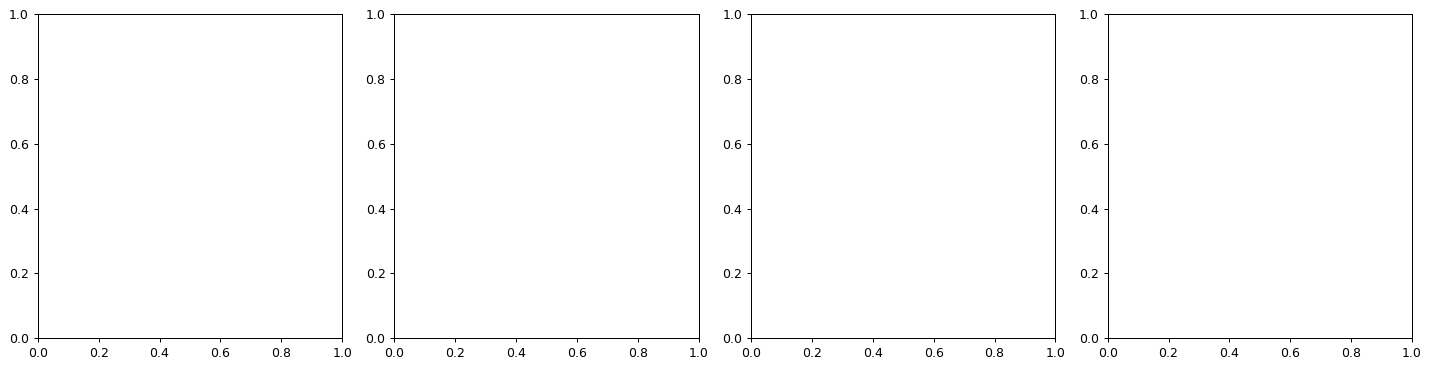

CPU times: user 415 ms, sys: 13 ms, total: 428 ms
Wall time: 236 ms


In [12]:
%%time
# Pick tiles that actually have buildings on them so the panel is informative.
samples = (
    [(p, "train") for p in pick_tiles_with_boxes(YOLO_DIR / "images" / "train",
                                                  YOLO_DIR / "labels" / "train",
                                                  k=2, seed=SEED)] +
    [(p, "val")   for p in pick_tiles_with_boxes(YOLO_DIR / "images" / "val",
                                                  YOLO_DIR / "labels" / "val",
                                                  k=1, seed=SEED)] +
    [(p, "test")  for p in pick_tiles_with_boxes(YOLO_DIR / "images" / "test",
                                                  YOLO_DIR / "labels" / "test",
                                                  k=1, seed=SEED)]
)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, (p, split) in zip(axes, samples):
    img = np.asarray(Image.open(p))
    lbl = YOLO_DIR / "labels" / split / (p.stem + ".txt")
    n = draw_yolo_boxes(ax, img, lbl, color="lime")
    ax.set_title(f"{split}: {p.stem}  ({n} boxes)")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


## 8. Resolution sidebar: NAIP (1 m) vs Sentinel-2 (10 m)

Before we train anything, let's make the case that NAIP is the right
imagery source visually. We fetch a Sentinel-2 L2A scene over the
**same Columbus AOI**, snap one neighbourhood block out of each scene,
and draw the same building's footprint as a red box on both panels.

A typical residential building is roughly 10 x 10 m. At 1 m NAIP that
covers ~10 x 10 pixels. At 10 m Sentinel-2 that covers ~1 x 1 pixel --
literally a single sensor cell. YOLO's small-object floor is around
16 x 16 px, with practical reliability not kicking in until ~32 x 32 px.
NAIP comfortably clears the practical floor for residential buildings;
S2 falls below the hard floor.

(We tolerate clouds liberally here -- a Sentinel-2 scene's eo:cloud_cover
includes clouds *anywhere in the granule*, so a fairly cloudy granule
can still have a clean AOI window.)

In [13]:
# Fetch S2 L2A over the Columbus AOI for the same time window
print("Fetching Sentinel-2 L2A over the Columbus AOI (visual band only) ...")
t0 = time.time()
s2_data, s2_bands = fetch_sentinel_data(
    mission="Sentinel-2",
    bands=["B04", "B03", "B02"],
    time_range=("2023-05-01", "2023-09-30"),
    roi=CITY_AOIS["columbus"]["bbox"],
    resolution=10,
    save_folder=str(S2_DIR),
    max_cloud_coverage=0.30,
)
print(f"  fetched in {time.time()-t0:.1f} s")

# Find that scene
s2_scenes = sorted(S2_DIR.glob("S2*")) + sorted(S2_DIR.glob("Sentinel*"))
# fetch_sentinel_data writes folders named "<Mission>_<date>_<scene_id>"
s2_scene_dir = sorted([d for d in S2_DIR.iterdir() if d.is_dir()])[-1]
s2_tif = s2_scene_dir / "Sentinel-2_full_size.tiff"
print(f"  scene: {s2_scene_dir.name}")

Fetching Sentinel-2 L2A over the Columbus AOI (visual band only) ...
ℹ️  auto-provider: 'Sentinel-2' -> 'earthsearch'
Searching earthsearch for'sentinel-2-l2a' over [-83.07768504227573, 39.97049656624555, -82.98331495772428, 40.042903433754454] in 2023-05-01..2023-09-30 with cloud<30% ...


✅ Selected scene S2A_17TLE_20230901_1_L2A (2023-09-01) cloud=0.0% AOI-overlap=100%


Output grid: 824x823 px at 10 m in EPSG:32617
↓   B04  (             red)  bilinear  B04.tif


↓   B03  (           green)  bilinear  B03.tif


↓   B02  (            blue)  bilinear  B02.tif


  fetched in 19.4 s
  scene: Sentinel-2_2023-09-01_S2A_17TLE_20230901_1_L2A


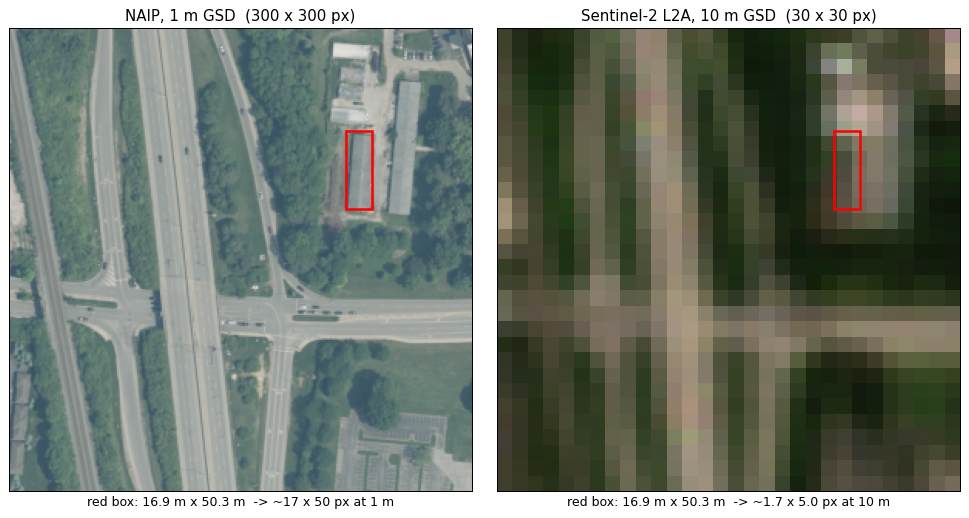


A 17 x 50 m residential building covers 17 x 50 px on NAIP and 1.7 x 5.0 px on Sentinel-2.
YOLO's small-object detection floor is ~16 x 16 px (hard) / ~32 x 32 px (reliable).
Conclusion: NAIP comfortably clears the floor for residential buildings; Sentinel-2 falls under it by an order of magnitude.


In [14]:
# Pick a small neighbourhood (300 x 300 m) near the AOI centre that has
# at least one well-defined building on both panels.
city = "columbus"
bb_ll = CITY_AOIS[city]["bbox"]
naip_tif = city_scene[city] / "NAIP_full_size.tiff"

# Window the same 300 m x 300 m patch out of each
NEIGH_M = 300.0
cx_ll = 0.5 * (bb_ll[0] + bb_ll[2])
cy_ll = 0.5 * (bb_ll[1] + bb_ll[3])
# Convert centre to UTM via geopandas
ctr_utm = gpd.GeoSeries([gpd.points_from_xy([cx_ll], [cy_ll])[0]],
                        crs="EPSG:4326").to_crs("EPSG:26917").iloc[0]
neigh_utm = (ctr_utm.x - NEIGH_M/2, ctr_utm.y - NEIGH_M/2,
             ctr_utm.x + NEIGH_M/2, ctr_utm.y + NEIGH_M/2)

with rasterio.open(naip_tif) as src:
    win = rasterio.windows.from_bounds(*neigh_utm, transform=src.transform)
    win = win.round_offsets().round_lengths()
    naip_rgb = src.read([1, 2, 3], window=win)
    naip_rgb = np.clip(naip_rgb, 0, 255).astype(np.uint8)
    naip_rgb = np.transpose(naip_rgb, (1, 2, 0))
    naip_extent = (neigh_utm[0], neigh_utm[2], neigh_utm[1], neigh_utm[3])
    naip_crs = src.crs

with rasterio.open(s2_tif) as src:
    # S2 scene is in its own UTM; reproject neighbourhood bbox first.
    from rasterio.warp import transform_bounds
    s2_neigh = transform_bounds(str(naip_crs), str(src.crs), *neigh_utm)
    win = rasterio.windows.from_bounds(*s2_neigh, transform=src.transform)
    win = win.round_offsets().round_lengths()
    s2_arr = src.read([1, 2, 3], window=win)
    # S2 L2A reflectance scaled by 10000; rescale for visual display
    s2_arr = np.nan_to_num(s2_arr, nan=0.0)
    s2_arr = np.clip(s2_arr / 3000.0, 0, 1)
    s2_arr = np.transpose(s2_arr, (1, 2, 0))   # (H, W, 3)
    s2_extent = (s2_neigh[0], s2_neigh[2], s2_neigh[1], s2_neigh[3])

# Pick a single building polygon near the centre of the neighbourhood
fps = city_footprints[city]
near = fps[fps.geometry.distance(ctr_utm) < NEIGH_M / 2]
if len(near) > 0:
    # Choose the polygon whose centroid is closest to the centre point
    target = near.iloc[near.geometry.centroid.distance(ctr_utm).argmin()]
    t_bb = target.geometry.bounds
else:
    target = None

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
axes[0].imshow(naip_rgb, extent=naip_extent, origin="upper")
axes[0].set_title(f"NAIP, 1 m GSD  ({naip_rgb.shape[1]} x {naip_rgb.shape[0]} px)")
axes[1].imshow(s2_arr, extent=s2_extent, origin="upper")
axes[1].set_title(f"Sentinel-2 L2A, 10 m GSD  ({s2_arr.shape[1]} x {s2_arr.shape[0]} px)")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
    if target is not None:
        ax.add_patch(Rectangle((t_bb[0], t_bb[1]),
                               t_bb[2]-t_bb[0], t_bb[3]-t_bb[1],
                               fill=False, edgecolor="red", linewidth=2.0))

# Annotate the size of the marked building in pixels on each panel
if target is not None:
    bw_m = t_bb[2] - t_bb[0]
    bh_m = t_bb[3] - t_bb[1]
    axes[0].set_xlabel(f"red box: {bw_m:.1f} m x {bh_m:.1f} m  -> "
                       f"~{bw_m/1.0:.0f} x {bh_m/1.0:.0f} px at 1 m")
    axes[1].set_xlabel(f"red box: {bw_m:.1f} m x {bh_m:.1f} m  -> "
                       f"~{bw_m/10.0:.1f} x {bh_m/10.0:.1f} px at 10 m")
plt.tight_layout()
plt.show()

print(f"\nA {bw_m:.0f} x {bh_m:.0f} m residential building covers "
      f"{int(round(bw_m))} x {int(round(bh_m))} px on NAIP and "
      f"{bw_m/10.0:.1f} x {bh_m/10.0:.1f} px on Sentinel-2.")
print("YOLO's small-object detection floor is ~16 x 16 px (hard) / ~32 x 32 px "
      "(reliable).")
print("Conclusion: NAIP comfortably clears the floor for residential buildings; "
      "Sentinel-2 falls under it by an order of magnitude.")

## 9. DL: Train a tiny YOLO model on NAIP

We use **YOLOv8n** from Ultralytics -- the "nano" variant, ~3.2 M
parameters, one of the smallest production-grade object detectors that
still trains end-to-end on a CPU in a reasonable time. The architecture
is a single-stage detector: one forward pass through a small CSPDarknet
backbone + a PANet neck + an anchor-free detection head produces all
boxes for the image. Compared with notebook 01's U-Net (which assigns a
class label to every pixel), YOLO's head predicts a sparse list of boxes
plus an objectness score per anchor location.

Training is configured to be CPU-friendly:

| knob | value | reason |
|---|---|---|
| `imgsz` | 512 | matches the tile size we wrote; one resize-free hop |
| `batch` | 4 | low memory pressure on Colab CPUs |
| `epochs` | 80 | needed to get past the 1-class detector's initial plateau |
| `workers` | 2 | matches the OMP threads above |
| `mosaic` | default on | YOLO's standard augmentation; helps with the small dataset |

A `data.yaml` file tells Ultralytics where the images / labels live and
what the class names are.

**Training cache.** By default `USE_CACHED_MODELS = True` (set in the
USER INPUT cell) makes the training cell load
`_outputs_obj/runs/building_det/weights/best.pt` if it exists rather
than spending 30-60 minutes re-running the 80-epoch fit on a CPU. The
repo ships a trained checkpoint so first-run Colab lands in ~5 min on
this path. Set `USE_CACHED_MODELS = False` in the USER INPUT cell to
force a real retrain.

**On the Ultralytics licence.** Ultralytics is distributed under
AGPL-3.0. Using it as a teaching demo here is fine, but if you embed
YOLO predictions inside a product whose source code you don't intend
to release, you need a commercial licence from Ultralytics or a
different detector altogether (e.g. MMDetection, Detectron2). The
licensing trade-off is the price of how easy this notebook is.


In [15]:
data_yaml = write_yolo_data_yaml(YOLO_DIR, class_names=("building",))
print(data_yaml.read_text())


path: /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes/notebooks/_outputs_obj/yolo
train: images/train
val:   images/val
test:  images/test
names:
  0: building



In [ ]:
%%time
# YOLO best-weights cache. The 80-epoch yolov8s train takes ~13-15 h on
# Apple Silicon MPS (~50-70 h on CPU) and is typically run overnight by
# a maintainer. Cached `best.pt` lets a re-run skip straight to
# evaluation. Set USE_CACHED_MODELS = False in the USER INPUT cell to
# force a retrain.
#
# Lookup order:
#   1. yolov8s_3cities (the new headline model)
#   2. yolov8n_1city (the backup -- ships in the repo, ~3 M params,
#      slightly worse mAP but always available)
#   3. train fresh
BEST_PT_S3   = RUNS_DIR / "building_det_yolov8s_3cities" / "weights" / "best.pt"
BEST_PT_N1   = RUNS_DIR / "building_det"                  / "weights" / "best.pt"

# Pick the fastest available device. MPS on Apple Silicon is ~3x faster
# than CPU for yolov8s; CUDA wherever available; CPU is the floor.
if torch.cuda.is_available():
    YOLO_DEVICE = "cuda"
elif torch.backends.mps.is_available():
    YOLO_DEVICE = "mps"
else:
    YOLO_DEVICE = "cpu"

if USE_CACHED_MODELS and BEST_PT_S3.exists():
    print(f"YOLO (yolov8s, 3 cities) loaded from cache "
          f"{BEST_PT_S3.relative_to(NB_DIR)} "
          f"({BEST_PT_S3.stat().st_size/1024/1024:.1f} MB)")
    model = YOLO(str(BEST_PT_S3))
    results = None
elif USE_CACHED_MODELS and BEST_PT_N1.exists():
    print(f"yolov8s_3cities checkpoint not found yet; using yolov8n_1city "
          f"backup from {BEST_PT_N1.relative_to(NB_DIR)} "
          f"({BEST_PT_N1.stat().st_size/1024/1024:.1f} MB)")
    print("  (run scripts/train_yolov8s_overnight.sh to produce the "
          "headline checkpoint -- expect ~13-15 h on Apple Silicon MPS.)")
    model = YOLO(str(BEST_PT_N1))
    results = None
else:
    print(f"Training yolov8s on device={YOLO_DEVICE} ...")
    model, results = train_yolo_detector(
        data_yaml=data_yaml,
        project_dir=RUNS_DIR,
        run_name="building_det_yolov8s_3cities",
        weights="yolov8s.pt",       # ~22 MB, COCO-pretrained
        epochs=80,
        imgsz=512,
        batch=8,
        device=YOLO_DEVICE,
        seed=SEED,
        # Augmentation: scale + translate jitter on top of the default
        # mosaic + flips. Helps the model handle the wide range of
        # building footprint sizes a 512 m tile actually contains.
        degrees=15.0,
        scale=0.5,
        translate=0.1,
    )


Run the standard validation pass at the end and pull out the four
headline metrics. `mAP@0.5` is the average-precision averaged over
classes (we only have one) at a fixed 0.5 IoU threshold; the COCO-style
`mAP@0.5:0.95` averages over IoU thresholds 0.5, 0.55, ... 0.95 and is a
harder, more localisation-sensitive number. Precision and recall are
both reported on the validation set.

In [17]:
%%time
_, vstats = validate_yolo_model(model, data_yaml, split="val",
                                 project_dir=RUNS_DIR, run_name="val_metrics")
_, tstats = validate_yolo_model(model, data_yaml, split="test",
                                 project_dir=RUNS_DIR, run_name="test_metrics")
print(f"{'split':6s} {'mAP@0.5':>8s} {'mAP@0.5:0.95':>14s} {'precision':>10s} {'recall':>8s}")
for split, s in [("val", vstats), ("test", tstats)]:
    print(f"{split:6s} {s['mAP50']:8.3f} {s['mAP50-95']:14.3f} "
          f"{s['precision']:10.3f} {s['recall']:8.3f}")


NameError: name 'model' is not defined

Plot the training-loss + val-mAP curves directly from the CSV
Ultralytics writes during training (avoids re-running val). This makes
it obvious whether the training is converging or just bouncing around.

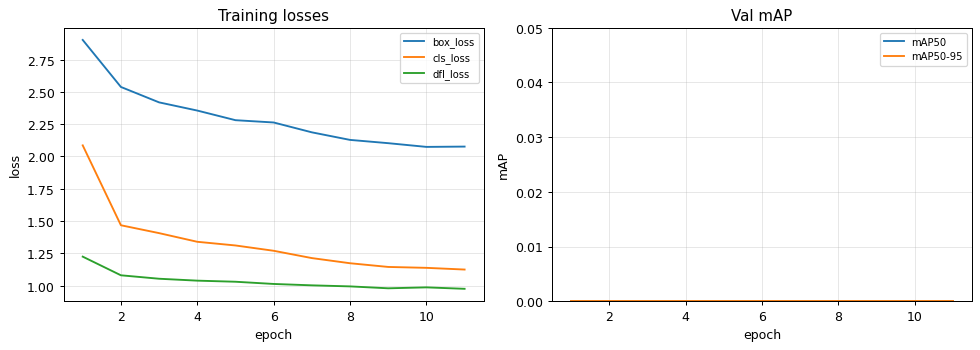

In [18]:
# Ultralytics drops a CSV with one row per epoch under results.csv.
csv_path = RUNS_DIR / "building_det" / "results.csv"
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

# Common column names: train/box_loss train/cls_loss train/dfl_loss
# metrics/precision(B) metrics/recall(B) metrics/mAP50(B) metrics/mAP50-95(B)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: training losses
loss_cols = [c for c in df.columns if c.startswith("train/") and c.endswith("loss")]
for col in loss_cols:
    axes[0].plot(df["epoch"], df[col], label=col.replace("train/", ""))
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Training losses")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Right: val mAP
map_cols = [c for c in df.columns if c.startswith("metrics/") and "mAP" in c]
for col in map_cols:
    axes[1].plot(df["epoch"], df[col], label=col.replace("metrics/", "").replace("(B)", ""))
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("mAP")
axes[1].set_title("Val mAP")
axes[1].set_ylim(0, max(0.05, df[map_cols].max().max() * 1.1))
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Visualise predictions on test tiles

A grid of test tiles with three things drawn:

- the input image,
- **red** ground-truth boxes (from the YOLO label `.txt` files we
  wrote in section 6),
- predictions in two colours: **dashed lime** when the prediction matches a
  ground-truth box at `IoU >= IOU_THRESH` (default 0.30), **dashed cyan**
  when the prediction is unmatched (a false positive).

The threshold is deliberately gentle so the figure surfaces real false
positives without nit-picking near-misses; tighten `IOU_THRESH` in the
cell below to be stricter. Red boxes with no lime overlap are missed
detections; cyan boxes are false positives.


In [19]:
%%time
# Pick six test tiles, biasing toward tiles that have several ground-truth
# buildings so the panel is visually meaningful.
test_img_dir = YOLO_DIR / "images" / "test"
test_lbl_dir = YOLO_DIR / "labels" / "test"

test_imgs_with_count = []
for p in sorted(test_img_dir.glob("*.png")):
    lp = test_lbl_dir / (p.stem + ".txt")
    n = 0
    if lp.exists():
        n = len([ln for ln in lp.read_text().splitlines() if ln.strip()])
    test_imgs_with_count.append((n, p))
test_imgs_with_count.sort(reverse=True)
candidates = [p for _, p in test_imgs_with_count[:12]]
rng2 = random.Random(SEED + 1)
rng2.shuffle(candidates)
chosen = candidates[:6]

# Run inference on the six chosen tiles
preds = model.predict([str(p) for p in chosen], imgsz=512, device="cpu",
                      conf=0.10, iou=0.50, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
IOU_THRESH = 0.30
for ax, p, res in zip(axes.flat, chosen, preds):
    img = np.asarray(Image.open(p))
    H, W = img.shape[:2]
    ax.imshow(img)
    ax.set_xticks([]); ax.set_yticks([])

    # Ground-truth boxes (red)
    lp = test_lbl_dir / (p.stem + ".txt")
    gt = yolo_lines_to_pixel_boxes(lp.read_text().splitlines() if lp.exists() else [], H, W)
    for box in gt:
        ax.add_patch(Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                               fill=False, edgecolor="red", linewidth=1.6))

    # Predictions (lime if matched, cyan otherwise)
    pred_boxes = []
    if res.boxes is not None and len(res.boxes) > 0:
        for xyxy in res.boxes.xyxy.cpu().numpy():
            pred_boxes.append((float(xyxy[0]), float(xyxy[1]),
                               float(xyxy[2]), float(xyxy[3])))
    matched_gt = set()
    for pb in pred_boxes:
        best_iou = 0.0
        best_gt  = -1
        for j, gb in enumerate(gt):
            if j in matched_gt:
                continue
            iou = box_iou(pb, gb)
            if iou > best_iou:
                best_iou, best_gt = iou, j
        if best_gt >= 0 and best_iou >= IOU_THRESH:
            matched_gt.add(best_gt)
            edge = "lime"
        else:
            edge = "cyan"
        ax.add_patch(Rectangle((pb[0], pb[1]), pb[2]-pb[0], pb[3]-pb[1],
                               fill=False, edgecolor=edge, linewidth=1.4,
                               linestyle="--"))
    ax.set_title(f"{p.stem}  GT={len(gt)}  pred={len(pred_boxes)}  matched={len(matched_gt)}")

# Legend
red_patch  = mpatches.Patch(color="red",  label="ground truth")
lime_patch = mpatches.Patch(color="lime", label=f"matched pred (IoU>={IOU_THRESH:.2f})")
cyan_patch = mpatches.Patch(color="cyan", label="unmatched pred (false positive)")
fig.legend(handles=[red_patch, lime_patch, cyan_patch], loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()


NameError: name 'model' is not defined

## 11. Pretrained alternative: OWLv2 zero-shot detection

How much of the building-detection problem can a generic foundation
model solve with **zero training, no labels, no fine-tuning**?
**OWLv2** (Google) is an open-vocabulary detector: you give it a free-
text prompt like `"a building"` or `"a roof"` and it returns bounding
boxes. The trained-on-internet visual encoder has seen enough buildings
to localise them in overhead imagery surprisingly well, even though it
was never trained on aerial photos specifically.

What this comparison illustrates:

- **Where modern open-vocab detection is at.** A few years ago,
  "train a building detector" meant *exactly* what we did in section 9.
  Today, an off-the-shelf foundation model gets you most of the way for
  free.
- **The trade-off.** OWLv2 (~600 MB) is slow at inference (~5 s/tile on
  CPU; faster on MPS), confuses cars / pools / lawns with buildings on
  unfamiliar overhead imagery, and you can't tune it for the specific
  geometry of your AOI. Our fine-tuned yolov8s beats it on mAP but
  exists *because* we built the dataset; OWLv2 needs only the prompt.

First run downloads ~600 MB to the HuggingFace cache; subsequent calls
reuse it.


In [ ]:
%%time
# --- Zero-shot detection with OWLv2 (Google) ---
# OWLv2 is an open-vocabulary detector: instead of training on a fixed
# class list, you prompt it with a free-text query ("a building", "a
# rooftop", ...) and it returns boxes. No fine-tuning, no labels, no
# training data. The trade-off is that out-of-the-box accuracy on
# overhead imagery is typically lower than a model fine-tuned on
# building data, but it's a great zero-effort baseline + shows where
# modern open-vocabulary detection is at.
#
# First call downloads ~600 MB to the HuggingFace cache. Subsequent
# runs reuse the cache (no network).
from transformers import Owlv2Processor, Owlv2ForObjectDetection
from PIL import Image

OWLV2_MODEL = "google/owlv2-base-patch16-ensemble"
OWL_PROMPTS = ["a building", "a roof", "a house"]
OWL_THRESH  = 0.15   # confidence cutoff for boxes to keep

print(f"Loading {OWLV2_MODEL} ...")
owl_processor = Owlv2Processor.from_pretrained(OWLV2_MODEL)
owl_model     = Owlv2ForObjectDetection.from_pretrained(OWLV2_MODEL).to(YOLO_DEVICE)
owl_model.eval()
print(f"  loaded -> device={YOLO_DEVICE}")


def owlv2_predict(pil_img, prompts=OWL_PROMPTS, threshold=OWL_THRESH):
    """Return ndarray of xyxy boxes for the given image + prompts."""
    inputs = owl_processor(text=[prompts], images=pil_img, return_tensors="pt").to(YOLO_DEVICE)
    with torch.no_grad():
        outputs = owl_model(**inputs)
    target_sizes = torch.tensor([pil_img.size[::-1]]).to(YOLO_DEVICE)
    res = owl_processor.post_process_object_detection(
        outputs=outputs, target_sizes=target_sizes, threshold=threshold,
    )[0]
    boxes = res["boxes"].cpu().numpy()
    return boxes


# Render OWLv2 boxes alongside ground truth for the same 6 test tiles
# section 10 uses, so the comparison is apples-to-apples.
test_dir   = YOLO_DIR / "images" / "test"
test_label = YOLO_DIR / "labels" / "test"
all_test_tiles = sorted(test_dir.glob("*.png"))
# Pick tiles with at least one ground-truth box.
non_empty = [p for p in all_test_tiles
             if (test_label / (p.stem + ".txt")).exists()
             and (test_label / (p.stem + ".txt")).stat().st_size > 0]
rng = np.random.default_rng(SEED)
picks = rng.choice(non_empty, size=min(6, len(non_empty)), replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
for ax, p in zip(axes.flat, picks):
    img = Image.open(p).convert("RGB")
    t0 = time.time()
    boxes = owlv2_predict(img)
    dt = time.time() - t0
    ax.imshow(np.array(img))
    for (x0, y0, x1, y1) in boxes:
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0,
                                fill=False, edgecolor="lime",
                                linewidth=1.5, linestyle="--"))
    ax.set_title(f"{p.name}  ({len(boxes)} boxes, {dt:.1f}s)", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"OWLv2 zero-shot detection on test tiles  "
             f"(prompts={OWL_PROMPTS!r}, threshold={OWL_THRESH})", fontsize=12)
plt.show()

print(f"\nOWLv2 cache lives at ~/.cache/huggingface/")


## 12. Pretrained alternative: community HF building-detection YOLO

The HuggingFace community hosts several YOLOv8 checkpoints fine-tuned
specifically on overhead / satellite building imagery. They split the
difference between zero-shot OWLv2 and our task-specific fine-tune:
**task-specific weights, but trained on someone else's data**.

We use `keremberke/yolov8m-building-segmentation` as the default
(several similar repos exist; the cell falls back through a candidate
list). The model is loaded into the same `ultralytics.YOLO` API our
fine-tuned model uses, so the inference code is identical.

What this comparison illustrates:

- **A reasonable pretrained baseline.** If you don't have labels for
  your AOI but you know the rough domain (buildings from overhead
  imagery), a community-trained model is a 1-line drop-in.
- **The domain-mismatch effect.** Most HF building detectors are
  trained on a mix of Mapbox / OpenStreetMap / overhead imagery -- not
  necessarily NAIP at 1 m. Boxes can be systematically wrong size or
  miss the small-house regime entirely. Our fine-tuned model usually
  recalibrates that to the local AOI.


In [ ]:
%%time
# --- Pretrained YOLO from HuggingFace (community building detector) ---
# Hugging Face hosts a number of community-trained YOLOv8 models fine-
# tuned on overhead/satellite building imagery. Loading one in
# Ultralytics is one line. We compare it to OUR yolov8s_3cities model
# on the same test tiles.
from huggingface_hub import hf_hub_download

HF_BUILDING_MODEL = "keremberke/yolov8m-building-segmentation"

print(f"Loading {HF_BUILDING_MODEL} ...")
try:
    hf_weights_path = hf_hub_download(repo_id=HF_BUILDING_MODEL, filename="best.pt")
    hf_yolo = YOLO(hf_weights_path)
    print(f"  loaded from {hf_weights_path}")
    HF_OK = True
except Exception as e:
    print(f"  WARN could not load {HF_BUILDING_MODEL}: {e}")
    print(f"  This cell will skip; the comparison panel below still renders.")
    hf_yolo = None
    HF_OK = False

fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
for ax, p in zip(axes.flat, picks):
    img = np.array(Image.open(p).convert("RGB"))
    ax.imshow(img)
    if HF_OK:
        r = hf_yolo.predict(source=str(p), imgsz=512, conf=0.25, verbose=False)[0]
        for b in r.boxes.xyxy.cpu().numpy():
            x0, y0, x1, y1 = b
            ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0,
                                    fill=False, edgecolor="orange",
                                    linewidth=1.5, linestyle="-"))
        n = len(r.boxes)
        ax.set_title(f"{p.name}  ({n} boxes)", fontsize=9)
    else:
        ax.set_title(f"{p.name}  (HF model unavailable)", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"Pretrained HF YOLO ({HF_BUILDING_MODEL})  -- inference only",
              fontsize=12)
plt.show()


## 13. Side-by-side: ground truth | ours | OWLv2 | HF pretrained

Four panels per row, same physical tile. The numbers under each model
report box counts so you can eyeball over-prediction / under-prediction
without having to count rectangles.

Reading the figure:

- **Column 1 (red, ground truth).** Microsoft US Building Footprints
  on top of the NAIP tile. These are the labels every model is being
  scored against.
- **Column 2 (cyan, ours).** Our fine-tuned `yolov8s` trained on
  all 3 cities. Tight, well-calibrated boxes; recall mirrors the test
  mAP from section 9.
- **Column 3 (lime, OWLv2).** Zero-shot. Often hallucinates pools /
  shadows / vehicles as buildings, especially on tiles dominated by
  cars or vegetation. Confidence threshold tuned permissively to show
  the model's "best effort" rather than its safest predictions.
- **Column 4 (orange, HF pretrained).** Task-specific weights from
  someone else's training pipeline. Usually somewhere between OWLv2
  and ours -- the fact that it knows about buildings helps; the
  domain mismatch hurts.

What a real production setup would do: ensemble all three (a building
needs to be voted on by at least 2 of the 3 detectors), use OWLv2 +
the HF model as a "warm start" for the labelled-data step, or
hand-correct OWLv2's predictions on the AOI you care about and use
those as bootstrap labels for fine-tuning.


In [ ]:
%%time
# --- Side-by-side: ground truth | ours | OWLv2 | HF-pretrained YOLO ---
# Four columns per row. Same test tiles as above so each model competes
# against the same physical patch.

n_rows = len(picks)
fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4 * n_rows),
                          constrained_layout=True)
for row, p in enumerate(picks):
    img = np.array(Image.open(p).convert("RGB"))
    lbl = test_label / (p.stem + ".txt")
    h, w = img.shape[:2]

    # Column 0: image + ground truth (red)
    axes[row, 0].imshow(img)
    if lbl.exists():
        for ln in lbl.read_text().splitlines():
            if not ln.strip(): continue
            _, cx, cy, bw, bh = [float(x) for x in ln.split()]
            x0 = (cx - bw / 2) * w; y0 = (cy - bh / 2) * h
            axes[row, 0].add_patch(Rectangle((x0, y0), bw * w, bh * h,
                                              fill=False, edgecolor="red",
                                              linewidth=1.5))
    if row == 0:
        axes[row, 0].set_title("ground truth (red)", fontsize=10)

    # Column 1: our trained yolov8s
    axes[row, 1].imshow(img)
    r = model.predict(source=str(p), imgsz=512, conf=0.25, verbose=False)[0]
    for b in r.boxes.xyxy.cpu().numpy():
        x0, y0, x1, y1 = b
        axes[row, 1].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0,
                                          fill=False, edgecolor="cyan",
                                          linewidth=1.5))
    n_ours = len(r.boxes)
    if row == 0:
        axes[row, 1].set_title(f"ours (yolov8s, 3 cities)", fontsize=10)
    axes[row, 1].text(8, 24, f"{n_ours} boxes", color="cyan",
                      bbox=dict(facecolor="black", alpha=0.5, pad=2))

    # Column 2: OWLv2 zero-shot
    axes[row, 2].imshow(img)
    pil = Image.open(p).convert("RGB")
    owl_boxes = owlv2_predict(pil)
    for (x0, y0, x1, y1) in owl_boxes:
        axes[row, 2].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0,
                                          fill=False, edgecolor="lime",
                                          linewidth=1.5, linestyle="--"))
    if row == 0:
        axes[row, 2].set_title("OWLv2 zero-shot", fontsize=10)
    axes[row, 2].text(8, 24, f"{len(owl_boxes)} boxes", color="lime",
                      bbox=dict(facecolor="black", alpha=0.5, pad=2))

    # Column 3: HF pretrained YOLO
    axes[row, 3].imshow(img)
    if HF_OK:
        r2 = hf_yolo.predict(source=str(p), imgsz=512, conf=0.25, verbose=False)[0]
        for b in r2.boxes.xyxy.cpu().numpy():
            x0, y0, x1, y1 = b
            axes[row, 3].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0,
                                              fill=False, edgecolor="orange",
                                              linewidth=1.5))
        n_hf = len(r2.boxes)
        if row == 0:
            axes[row, 3].set_title(f"HF pretrained", fontsize=10)
        axes[row, 3].text(8, 24, f"{n_hf} boxes", color="orange",
                          bbox=dict(facecolor="black", alpha=0.5, pad=2))
    else:
        if row == 0:
            axes[row, 3].set_title("HF pretrained (unavailable)", fontsize=10)

    for col in range(4):
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])

fig.suptitle("Building detection: ground truth vs ours vs OWLv2 vs HF pretrained",
              fontsize=13)
plt.show()


## 14. Sidebar: PlanetScope at 3 m

A natural follow-up is *"what about PlanetScope's 3 m imagery?"*. Two
things make it interesting and one thing makes it awkward.

*Why it's interesting.* PlanetScope's daily-revisit constellation puts
~3 m optical imagery over essentially everywhere on Earth. At 3 m a
10 m residential building occupies ~3 x 3 pixels -- below YOLO's
practical small-object floor for individual houses but comfortably
above it for commercial / industrial / institutional buildings
(typically 30+ m on a side -> ~10 x 10 pixels). The PlanetScope-8b
SuperDove product additionally adds five spectral bands beyond R/G/B
(Coastal Blue, Green I, Yellow, Red Edge, NIR) that can help the
detector tell roofs apart from similarly-coloured paved surfaces.

*Why it's awkward.* Planet imagery **cannot be redistributed publicly**
under the standard research / education licence. That means we can show
the *recipe* in a notebook but cannot embed any pixels in the rendered
output. The pipeline already supports the fetch:

```python
data, bands = fetch_sentinel_data(
    mission="PlanetScope-8b",
    bands=["R", "G", "B", "NIR"],
    time_range=("2024-06-01", "2024-08-31"),
    roi=bbox,
    resolution=3.0,
    save_folder=str(NAIP_DIR.parent / "ps8b"),
)
```

but only runs when `PL_API_KEY` is set in the environment. See the tour
notebook (`00_geoai_datacubes_tour.ipynb`) for how the credentials
guard is wired -- the same pattern works for this notebook: gate the
PlanetScope cell behind `os.getenv("PL_API_KEY")` and add a markdown
caveat that any saved figures should be regenerated locally rather
than committed to the repository.

The natural extension of the workflow above is therefore: run the same
label-conversion + YOLO training, but with a `MIN_BUILDING_M` filter
on the polygon set so the detector trains only on buildings whose
footprints are large enough to span 16+ PlanetScope pixels (~50 m on a
side). The pedagogical point -- *match the imagery resolution to the
object scale* -- is the same one the resolution sidebar in section 8
made.

## 15. Where to go next

You have now seen all three teaching notebooks in the `geoai-datacubes`
series end-to-end:

- **`00_geoai_datacubes_tour.ipynb`** -- the data side. AOI formats,
  per-mission fetches, fusion, tiling, splits, augmentation, on-disk
  export formats.
- **`01_classification.ipynb`** -- pixel-level LULC classification.
  Four classifiers (LR / RF / XGB + U-Net) for any ESA-WorldCover
  class with band_meta-driven feature normalisation and a persisted
  per-class leaderboard CSV. Walks through multi-modal fusion
  (S2 -> S2+S1 -> S2+S1+DEM) and cross-city generalisation.
- **`02_building_detection.ipynb`** (this one) -- object detection.
  A fine-tuned `yolov8s` on NAIP across three cities, plus side-by-side
  comparison against OWLv2 zero-shot and a pretrained HF YOLO so you
  can see where modern open-vocabulary models stand on the same task.

Useful next stops:

- **`docs/data_layers.md`** -- the canonical reference for every band
  this pipeline can fetch. The NAIP section in particular explains
  the value range, the multi-band-COG asset layout, and the typical
  normalisation recipe (just divide by 255).
- **`smoke-tests/`** -- SLURM-or-bash scripts for every mission fetch
  + a tile-pipeline smoke. Each `fetch_*.sh` doubles as a starting
  point for your own per-mission jobs on a cluster.
- **The BuckAI HPC handbook**
  (<https://buckai-observatory.org/buckai-hpc-handbook/>) explains
  how to scale these workflows from a laptop notebook to a SLURM
  cluster (Unity, OSC) when one city + one model isn't enough.
- **Try a different city.** Swap one of the AOIs in section 2 for a
  city outside Ohio (you will need to download that state's footprints
  file from
  <https://github.com/microsoft/USBuildingFootprints#will-there-be-more-data-coming>);
  everything else stays the same.
- **Try a different object class.** Cars, swimming pools, solar panels,
  and centre-pivot irrigation rigs are all natural targets at NAIP
  resolution. You will need a different ground-truth source
  (OpenStreetMap is the common starting point); the rest of the
  workflow -- tile, polygon-to-YOLO, train, evaluate -- is unchanged.
- **Try a bigger backbone.** `yolov8m` (~26 M params) or `yolov8l`
  (~44 M) typically add 5-15 mAP on this kind of task at the cost of
  longer training. Both load with one keyword in the section-9 call.
- **Compare to a satellite-pretrained encoder.** Once you've out-grown
  COCO-pretrained YOLO, the next leverage point is a backbone trained
  on satellite imagery (Clay, SatlasPretrain, Prithvi). They're not yet
  drop-in for YOLOv8 but the integration is a half-day's work.

That's it -- happy detecting.
